# CardioIA — Fase 2, Parte 2: Classificador de Risco por Texto

Este notebook treina um classificador básico que lê o relato de sintomas de um paciente e o classifica como **alto risco** ou **baixo risco**, simulando a priorização de uma triagem clínica.

**Fluxo:** base rotulada (`frases_risco.csv`) → TF-IDF → Regressão Logística → avaliação (acurácia, matriz de confusão e frases-desafio) → análise de vieses → integração com a Parte 1.

> **Aviso:** protótipo acadêmico treinado com frases simuladas. Não substitui avaliação médica.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (train_test_split, cross_val_score, cross_val_predict,
                                     RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pd.set_option("display.max_colwidth", None)  # mostra as frases inteiras nas tabelas

## 1. A base de frases

`frases_risco.csv` tem **100 frases curtas** com queixas comuns do dia a dia, escritas como o paciente falaria, metade rotulada como `alto risco` e metade como `baixo risco` (formato `frase,situacao`). As duas primeiras são os exemplos do enunciado.

Critério de rotulagem:
- **Alto risco:** pelo menos um sinal de alarme, como dor ou aperto no peito (principalmente em repouso, que irradia ou vem com suor frio), falta de ar súbita, ao deitar ou com as pernas inchadas, desmaio, coração disparado, sinais de AVC (boca torta, fala enrolada, perda súbita da visão, fraqueza de um lado do corpo), pressão muito alta com sintomas, perna inchada e quente de um lado só e quadros atípicos (cansaço extremo com suor frio, dor no queixo e no braço). Um sinal de alarme que já passou continua sendo alto risco. Os sinais de dor no peito se baseiam na *III Diretriz sobre Tratamento do Infarto Agudo do Miocárdio* (SBC, 2004), do corpus da [Fase 1](../../FASE-1/docs/).
- **Baixo risco:** sintomas leves e sem sinal de alarme, em geral com causa clara. Exemplos: dor muscular, gripe, dor de dente, cansaço por dormir mal, coração acelerado depois do café que já passou.

Incluímos de propósito alguns casos com palavras de alarme em contexto benigno, como "dor no peito só quando aperto o músculo, depois da academia". Também equilibramos as frases em que o paciente fala de si no masculino e no feminino ("estou cansado" / "estou cansada") dentro de cada classe, para o gênero não virar pista de risco, o mesmo cuidado que a Fase 1 teve com os ECGs.

In [2]:
df = pd.read_csv("frases_risco.csv")
print(df["situacao"].value_counts().to_string())
df.head(10)

situacao
alto risco     50
baixo risco    50


,frase,situacao
0,sinto dor no peito e falta de ar,alto risco
1,tive um leve incômodo nas costas,baixo risco
2,estou com um aperto no peito que vai para o braço esquerdo,alto risco
3,estou com dor nas costas depois de carregar peso,baixo risco
4,dor forte no peito há mais de meia hora e não passa,alto risco
5,meu pescoço dói de ficar muito tempo no computador,baixo risco
6,estou com dor no peito e suando frio,alto risco
7,estou com dor de cabeça leve depois de um dia cansativo,baixo risco
8,sinto um peso no peito e enjoo desde que acordei,alto risco
9,estou com o nariz escorrendo e espirrando muito,baixo risco


## 2. Separação entre treino e teste

75 frases (75%) servem para treinar e escolher o modelo; 25 (25%) ficam guardadas para o teste final. A divisão é **estratificada**: treino e teste ficam com quase metade de cada classe (no teste, 13 frases de alto risco e 12 de baixo risco).

In [3]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    df["frase"], df["situacao"], test_size=0.25, stratify=df["situacao"], random_state=42)
print(len(X_treino), "frases de treino |", len(X_teste), "frases de teste")

75 frases de treino | 25 frases de teste


## 3. TF-IDF e escolha do modelo

O **TF-IDF** transforma cada frase num vetor numérico, com uma posição para cada termo do vocabulário. O peso de um termo cresce quando ele aparece na frase (*TF*) e diminui quando ele é comum a muitas frases da base (*IDF*).

Configuração usada:
- `strip_accents="unicode"`: "coração" e "coracao" viram o mesmo termo. O vetorizador já converte tudo para minúsculas por padrão.
- `ngram_range=(1, 2)`: conta palavras isoladas e pares de palavras, como "falta de", "de ar" e "no peito".
- **Sem remover stopwords:** palavras como "não" e "sem" mudam o sentido do relato.
- O padrão do vetorizador ignora palavras de uma letra só ("e", "é"). Por isso aparece o par "peito falta" no exemplo mais abaixo.

O vetorizador fica dentro de um `Pipeline`, então, na validação cruzada, ele aprende o vocabulário só com a parte de treino de cada rodada.

Comparamos os dois modelos sugeridos no enunciado com **validação cruzada** no conjunto de treino: as 75 frases são divididas em 5 partes, cada parte é usada uma vez como validação, e o processo é repetido 10 vezes com sorteios diferentes. Com tão poucas frases, repetir deixa a comparação mais estável.

In [4]:
TFIDF = dict(strip_accents="unicode", ngram_range=(1, 2))
modelos = {
    "Regressão Logística": make_pipeline(TfidfVectorizer(**TFIDF), LogisticRegression(max_iter=1000)),
    "Árvore de Decisão": make_pipeline(TfidfVectorizer(**TFIDF), DecisionTreeClassifier(random_state=42)),
}
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
for nome, pipeline in modelos.items():
    acuracias = cross_val_score(pipeline, X_treino, y_treino, cv=cv)
    print(f"{nome}: acurácia média {acuracias.mean():.2f} (± {acuracias.std():.2f})")

Regressão Logística: acurácia média 0.79 (± 0.10)


Árvore de Decisão: acurácia média 0.67 (± 0.13)


A **Regressão Logística** foi melhor (0,79 contra 0,67). Ela soma os pesos de todos os termos da frase, enquanto a árvore decide por um termo de cada vez e, com poucos exemplos, decora detalhes que não se repetem. A Regressão Logística também dá a probabilidade de alto risco e pesos fáceis de interpretar. É o modelo escolhido.

Abaixo, treinamos o modelo com as 75 frases de treino e vemos como fica uma frase depois do TF-IDF: os 8 termos com maior peso no vetor.

In [5]:
modelo = modelos["Regressão Logística"].fit(X_treino, y_treino)
assert list(modelo.classes_) == ["alto risco", "baixo risco"]  # coluna 0 de predict_proba = alto risco

def prob_alto(frases):
    return modelo.predict_proba(frases)[:, 0]

tfidf = modelo[0]
print(len(tfidf.vocabulary_), "termos no vocabulário (palavras e pares de palavras)")
vetor = tfidf.transform(["sinto dor no peito e falta de ar"])
pd.Series(vetor.toarray()[0], tfidf.get_feature_names_out()).nlargest(8).round(2)

840 termos no vocabulário (palavras e pares de palavras)


peito falta    0.39
sinto dor      0.33
de ar          0.31
falta de       0.31
falta          0.30
sinto          0.28
ar             0.27
dor no         0.27
dtype: float64

## 4. Avaliação

### 4.1 Conjunto de teste

              precision    recall  f1-score   support

  alto risco       0.82      0.69      0.75        13
 baixo risco       0.71      0.83      0.77        12

    accuracy                           0.76        25
   macro avg       0.77      0.76      0.76        25
weighted avg       0.77      0.76      0.76        25



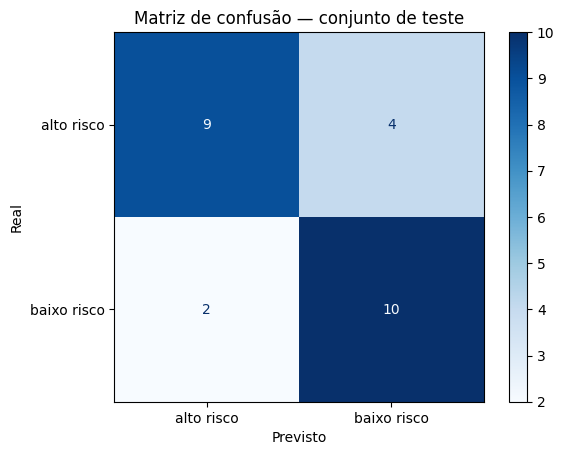

In [6]:
previsto = modelo.predict(X_teste)
print(classification_report(y_teste, previsto))
ConfusionMatrixDisplay.from_predictions(y_teste, previsto, cmap="Blues").ax_.set(
    title="Matriz de confusão — conjunto de teste", xlabel="Previsto", ylabel="Real")
plt.show()

No relatório: *precision* (precisão) = dos alertas de uma classe, quantos estavam certos; *recall* (sensibilidade) = dos casos de uma classe, quantos o modelo encontrou; *f1-score* = média harmônica das duas; *support* = número de frases da classe no teste.

Frases do teste que o modelo errou, com a probabilidade de alto risco calculada por ele:

In [7]:
teste = pd.DataFrame({"frase": X_teste, "real": y_teste, "previsto": previsto,
                      "prob_alto": prob_alto(X_teste).round(2)})
teste[teste["real"] != teste["previsto"]].sort_values("real")

,frase,real,previsto,prob_alto
14,acordo de madrugada sem ar e preciso sentar na cama,alto risco,baixo risco,0.50
20,quase desmaiei quando subi a escada,alto risco,baixo risco,0.49
76,"medi a pressão, deu 22 por 13, e estou meio confusa",alto risco,baixo risco,0.44
36,"estou com a perna inchada, vermelha e quente de um lado só",alto risco,baixo risco,0.47
33,"estou com cólica, como todo mês",baixo risco,alto risco,0.52
55,"estou com coriza e tosse, sem febre e sem falta de ar",baixo risco,alto risco,0.56


**Leitura dos resultados.** A acurácia no teste (0,76) ficou próxima da validação cruzada do treino (0,79). Numa triagem, porém, os dois tipos de erro não pesam igual:
- **Falsos negativos** (alto risco classificado como baixo) são o erro mais grave, porque o paciente com sinal de alarme vai para o fim da fila. Foram 4 de 13 casos graves (recall de 0,69: o modelo encontrou 69% dos casos de alto risco do teste).
- **Falsos positivos** (baixo risco classificado como alto) não põem em perigo o próprio paciente, mas ocupam a fila prioritária. Foram 2 de 12.

Nenhum dos casos graves perdidos cita o peito: falta de ar ao deitar, quase desmaio na escada, pressão 22 por 13 com confusão e perna inchada de um lado só. Um dos falsos alarmes é uma **negação**: em "coriza e tosse, sem febre e sem falta de ar", o modelo conta "falta de ar" como pista de alto risco mesmo negada.

### 4.2 Validação cruzada com as 100 frases

Com 25 frases no teste, cada erro muda a acurácia em 0,04. Para ter uma estimativa mais estável, usamos a **validação cruzada** na base inteira: as 100 frases são divididas em 5 partes, e cada frase é prevista por um modelo treinado **sem ela**.

In [8]:
previsto_cv = cross_val_predict(modelos["Regressão Logística"], df["frase"], df["situacao"],
                                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
print(classification_report(df["situacao"], previsto_cv))

              precision    recall  f1-score   support

  alto risco       0.82      0.82      0.82        50
 baixo risco       0.82      0.82      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100



Na validação cruzada, a acurácia foi de **0,82**, coerente com o teste (0,76) e com a validação do treino (0,79). O recall de alto risco ficou em **0,82** (41 dos 50 casos graves encontrados), uma estimativa mais estável que a do teste, que tem só 13 casos graves. Daqui em diante, quando precisarmos olhar as 100 frases, usamos essas previsões (`previsto_cv`), porque cada frase foi prevista por um modelo que não a viu.

## 5. O que o modelo aprendeu

Na Regressão Logística, cada termo recebe um peso. Como a classe "positiva" do modelo é `baixo risco` (a segunda em ordem alfabética), termos com peso **negativo** puxam a frase para **alto risco**. Os termos aparecem sem acento por causa do `strip_accents`.

In [9]:
pesos = pd.Series(modelo[-1].coef_[0], tfidf.get_feature_names_out()).sort_values()
pd.DataFrame({"puxam para ALTO risco": pesos.index[:12], "puxam para BAIXO risco": pesos.index[::-1][:12]})

,puxam para ALTO risco,puxam para BAIXO risco
0,peito,da
1,no peito,depois
2,no,por
3,ar,de
4,frio,depois de
5,dor no,por causa
6,ate,causa
7,ficaram,do
8,hora,passou
9,coracao,ja


Vários termos fazem sentido clínico: "peito", "no peito", "dor no", "ar" (de "falta de ar" e "sem ar") e "frio" (de "suor frio") indicam alto risco, enquanto "dói" (dor mecânica, como "dói quando mexo") indica baixo risco.

Também aparecem **distorções**, pistas que vêm do jeito como as frases foram escritas, e não da medicina:
- "por causa", "depois de" e "ontem" puxam para baixo risco porque as queixas leves costumam explicar a causa ("por causa da poeira", "depois da academia"). Um relato grave que comece com "depois do almoço…" perde pontos sem motivo clínico.
- "passou" e "já" puxam para baixo risco porque, nesta base, só os sintomas leves "já passaram". Mas um sinal de alarme que durou pouco, como um desmaio ou a boca torta por alguns minutos (pode ser um mini-AVC), continua sendo alto risco.
- "sem" puxa para alto risco por causa de "sem ar" e "sem força". Por isso, "sem febre e sem falta de ar" virou falso alarme no teste: o modelo não entende negação, só conta palavras e pares de palavras vizinhas.
- "no", "até", "hora", "ficaram" e "direito" são palavras genéricas que, nesta base, aparecem mais nas frases graves ("no peito", "até sentado", "há uma hora", "ficaram dormentes", "braço direito"). Por isso, "no futebol" ou "no banheiro" também contam como pista de risco.

Com uma base pequena, o modelo aprende **atalhos**, e eles funcionam até aparecer uma frase escrita de outro jeito.

## 6. Testando com frases novas

Para usar o modelo, basta passar frases. Troque ou acrescente frases na lista para testar outros relatos.

In [10]:
for frase in ["estou com uma pressão no peito que vai pro braço e suando frio",
              "meu joelho está doendo",
              "estou com dor de dente"]:
    print(f"{modelo.predict([frase])[0]:11} | {prob_alto([frase])[0]:.0%} | {frase}")

alto risco  | 65% | estou com uma pressão no peito que vai pro braço e suando frio
baixo risco | 45% | meu joelho está doendo
baixo risco | 44% | estou com dor de dente


### Frases-desafio

Para ver como o modelo se comporta diante de relatos de risco diferente, escritos de outras formas, criamos **10 frases-desafio** que não estão na base. Cada uma tenta pegar um atalho do modelo: negação, quadro atípico (sem a palavra "peito"), escrita de celular, palavra de alarme em contexto benigno, paciente que minimiza o sintoma, sinal de alarme que já passou, queixa não cardíaca e frase vaga.

In [11]:
DESAFIO = [
    ("não sinto dor no peito nem falta de ar, só uma coceira no braço", "baixo risco", "negação"),
    ("minha boca ficou torta por uns minutos, mas já passou", "alto risco", "já passou"),
    ("tenho 75 anos e bateu um cansaço tão grande que não consigo levantar da cadeira", "alto risco", "atípica"),
    ("parecia má digestão, mas estou pálido, gelado e com o estômago embrulhado há duas horas", "alto risco", "atípica"),
    ("dor no peto do nada e to suando frio", "alto risco", "sem acento / erro"),
    ("coracao disparou dps do cafe mas ja passou", "baixo risco", "sem acento / erro"),
    ("levei uma bolada no peito no futebol e só dói quando aperto", "baixo risco", "gatilho benigno"),
    ("deve ser bobagem, mas desmaiei agora há pouco no banheiro", "alto risco", "minimização"),
    ("a unha do pé está encravada e dói quando calço o tênis", "baixo risco", "queixa não cardíaca"),
    ("acordei meio indisposto, mas é só preguiça", "baixo risco", "vaga"),
]
desafio = pd.DataFrame(DESAFIO, columns=["frase", "esperado", "categoria"])
desafio["previsto"] = modelo.predict(desafio["frase"])
desafio["prob_alto"] = prob_alto(desafio["frase"]).round(2)
desafio["acertou"] = desafio["esperado"] == desafio["previsto"]
print(f"Acerto nas frases-desafio: {desafio['acertou'].sum()} de {len(desafio)}")
desafio

Acerto nas frases-desafio: 6 de 10


,frase,esperado,categoria,previsto,prob_alto,acertou
0,"não sinto dor no peito nem falta de ar, só uma coceira no braço",baixo risco,negação,alto risco,0.68,False
1,"minha boca ficou torta por uns minutos, mas já passou",alto risco,já passou,baixo risco,0.44,False
2,tenho 75 anos e bateu um cansaço tão grande que não consigo levantar da cadeira,alto risco,atípica,baixo risco,0.46,False
3,"parecia má digestão, mas estou pálido, gelado e com o estômago embrulhado há duas horas",alto risco,atípica,alto risco,0.50,True
4,dor no peto do nada e to suando frio,alto risco,sem acento / erro,alto risco,0.62,True
5,coracao disparou dps do cafe mas ja passou,baixo risco,sem acento / erro,baixo risco,0.41,True
6,levei uma bolada no peito no futebol e só dói quando aperto,baixo risco,gatilho benigno,alto risco,0.54,False
7,"deve ser bobagem, mas desmaiei agora há pouco no banheiro",alto risco,minimização,alto risco,0.52,True
8,a unha do pé está encravada e dói quando calço o tênis,baixo risco,queixa não cardíaca,baixo risco,0.39,True
9,"acordei meio indisposto, mas é só preguiça",baixo risco,vaga,baixo risco,0.44,True


O modelo acertou 6 de 10. Foi bem na queixa não cardíaca e na escrita de celular, mais pelas palavras conhecidas que sobraram ("já passou" numa frase, "suando frio" na outra) do que por entender a grafia: "peto" e "dps" ele nem reconhece. Dois acertos foram no limite: a minimização ("deve ser bobagem, mas desmaiei…", 0,52) e a "má digestão" (0,50), em que "pálido" e "estômago" nem estão no vocabulário. As quatro falhas repetem as distorções da seção 5:
- **Negação:** "não sinto dor no peito nem falta de ar, só uma coceira no braço" foi para alto risco (0,68). Para o modelo, a frase tem "dor no peito" e "falta de ar"; o "não" do começo não muda nada.
- **Sinal que já passou:** "minha boca ficou torta por uns minutos, mas já passou" foi para baixo risco (0,44). "Boca torta" está no treino como alto risco, mas "passou", "já" e "mas" só aparecem em queixas leves. Boca torta que melhora em minutos pode ser um mini-AVC e continua sendo urgente.
- **Gatilho benigno:** a "bolada no peito no futebol" foi para alto risco por causa de "no" e "peito".
- **Quadro atípico:** "tenho 75 anos e bateu um cansaço tão grande…" ficou em baixo risco (0,46). Sem "peito" nem "falta de ar", o modelo não reconhece o alarme.

## 7. Vieses e qualidade dos dados

Na Fase 1, o grupo equilibrou os ECGs em 50% mulheres e 50% homens para o modelo não associar o infarto a um padrão só masculino (ver [README da Fase 1](../../FASE-1/README.md)). Com texto, o viés aparece na **forma como o sintoma é contado**. A diretriz de IAM do nosso corpus diz que "cerca de 75% a 85% dos pacientes apresentam dor torácica como sintoma predominante". Os outros chegam com outra queixa principal, e quadros sem dor no peito são mais frequentes em mulheres, idosos e diabéticos (Canto et al., 2000; Mehta et al., 2016; referências no README).

Usando as previsões da validação cruzada (seção 4.2), comparamos quanto do alto risco o modelo encontra quando a frase cita o peito e quando não cita:

In [12]:
alto = df["situacao"] == "alto risco"
cita_peito = df["frase"].str.contains("peito")
for grupo, filtro in [("cita o peito", alto & cita_peito), ("não cita o peito", alto & ~cita_peito)]:
    print(f"alto risco que {grupo}: {(previsto_cv[filtro] == 'alto risco').sum()} de {filtro.sum()} detectados")
df[alto & ~cita_peito & (previsto_cv == "baixo risco")]

alto risco que cita o peito: 17 de 17 detectados
alto risco que não cita o peito: 24 de 33 detectados


,frase,situacao
16,estou com falta de ar e as pernas muito inchadas,alto risco
18,desmaiei hoje de manhã sem motivo,alto risco
26,minha boca ficou torta e a fala está enrolada,alto risco
30,minha pressão está 20 por 12 e estou com muita dor de cabeça,alto risco
36,"estou com a perna inchada, vermelha e quente de um lado só",alto risco
48,perdi os sentidos fazendo caminhada e caí na calçada,alto risco
76,"medi a pressão, deu 22 por 13, e estou meio confusa",alto risco
78,do nada tudo ficou preto e acordei no chão do quarto,alto risco
90,quase apaguei na mesa do trabalho e fiquei todo suado,alto risco


O modelo encontra todos os casos graves que citam o peito (17 de 17), mas deixa passar 9 dos 33 que não citam. Os que escaparam são desmaios, pressão muito alta, AVC, falta de ar com pernas inchadas e perna inchada de um lado só. Isso acontece mesmo com a maioria das frases graves sem a palavra "peito": ela se repete em 17 frases, enquanto desmaio, AVC e pressão alta aparecem em poucas frases cada, com palavras variadas ("desmaiei", "perdi os sentidos", "tudo ficou preto", "apaguei").

O modelo não tem um "preconceito" próprio: ele reproduz o que está mais representado nos dados. Se a base tivesse ainda menos exemplos sem dor no peito, o sistema deixaria no fim da fila justamente quem chega com outra queixa, o que inclui mais mulheres, idosos e diabéticos. Por isso, além da acurácia geral, é preciso **medir o desempenho por subgrupo**. Isso faz parte da **governança de dados**, junto com outros cuidados:
- **Representatividade:** a base precisa de vários exemplos de cada tipo de sinal de alarme, não só do quadro clássico.
- **Gênero no texto:** para o TF-IDF, "cansado" e "cansada" são palavras diferentes. Por isso equilibramos as frases no masculino e no feminino em cada classe, como a Fase 1 fez com os ECGs.
- **Qualidade dos rótulos:** as frases foram escritas e rotuladas pelo grupo, sem validação de um profissional de saúde.
- **Distribuição irreal:** a base tem 50% de alto risco, bem acima do que chega a uma triagem real.
- **Privacidade:** com relatos reais, os dados teriam de ser anonimizados, porque dado de saúde é dado sensível (LGPD, art. 11).

## 8. Integração com a Parte 1

A [Parte 1](../Parte-1/) sugere um **diagnóstico** a partir de 10 relatos de pacientes. Aqui aplicamos o classificador nesses mesmos relatos, que não estão na base, para obter o **nível de risco**. Todos descrevem quadros que pedem avaliação médica rápida.

In [13]:
relatos = [l for l in open("../Parte-1/frases_sintomas.txt", encoding="utf-8").read().splitlines() if l.strip()]
pd.DataFrame({"relato": relatos, "risco": modelo.predict(relatos), "prob_alto": prob_alto(relatos).round(2)},
             index=range(1, len(relatos) + 1))

,relato,risco,prob_alto
1,"Desde hoje de manhã sinto um aperto no peito muito forte que irradia para o braço esquerdo, com suor frio e enjoo, e não consegui sair da cama para ir trabalhar.",alto risco,0.64
2,"Há dois dias estou com uma dor no peito que piora quando faço esforço físico, como subir escadas, e alivia quando paro para descansar; não tenho falta de ar nem tontura, mas já deixei de fazer minha caminhada diária.",alto risco,0.58
3,"Sinto cansaço constante há uma semana, mesmo depois de descansar, e estou com os tornozelos inchados no fim do dia; à noite acordo com falta de ar e já não consigo trabalhar o dia inteiro.",alto risco,0.53
4,"Desde ontem à tarde sinto o coração disparado e batendo descompassado, com tontura quando levanto rápido, mas nunca desmaiei; parei de dirigir porque tenho medo de passar mal no trânsito.",baixo risco,0.44
5,"Há três dias acordo com dor na nuca e dor de cabeça, a visão fica embaçada e sinto um zumbido no ouvido, mas não tive sangramento no nariz; a pressão medida na farmácia deu 18 por 11 e precisei faltar ao trabalho.",baixo risco,0.47
6,"Faz quatro dias que tenho uma dor no peito que piora quando deito e quando respiro fundo, mas melhora quando inclino o corpo para frente; tive febre no início da semana e estou dormindo sentado no sofá.",alto risco,0.55
7,"Voltei de uma viagem de avião de doze horas no fim de semana e desde então estou com a perna esquerda inchada, dor na panturrilha e a pele vermelha e quente; está difícil até caminhar dentro de casa.",alto risco,0.51
8,"Hoje à tarde tive uma falta de ar repentina, com dor no peito ao respirar, e estou tossindo sangue; operei o joelho há duas semanas e desde então passo o dia deitado, mas estou sem febre.",alto risco,0.63
9,"Há uma hora percebi no espelho que estou com a boca torta, minha fala ficou enrolada e sinto fraqueza no braço direito; não consegui nem segurar a xícara de café.",alto risco,0.65
10,"Há duas semanas tenho febre que vai e volta, com calafrios e suor à noite, e apareceram manchas vermelhas nos dedos; fiz um tratamento de canal no mês passado e ando tão fraco que parei de ir à academia.",alto risco,0.52


O modelo marcou 8 dos 10 relatos como alto risco. Os dois que escaparam são o da arritmia (relato 4, 0,44) e o da pressão alta (relato 5, 0,47). A pressão alta repete o erro da seção 7: as duas frases graves de pressão da base também escaparam. Já as frases curtas de coração disparado o modelo acerta; o relato 4 caiu por atalhos de escrita ("ontem", "mas", "quando" puxam para baixo risco) e porque palavras como "tontura" e "descompassado" nem estão no vocabulário (a base só tem "tonto" e "tonta").

Uma ressalva: todos os relatos da Parte 1 são graves, então este teste mostra se o modelo encontra os casos graves, mas não se ele separa graves de leves. Os relatos também são bem mais longos que as frases de treino, e as probabilidades ficam entre 0,44 e 0,65.

Juntas, as duas partes formam um apoio à triagem: a Parte 1 indica **o que** pode ser, e a Parte 2 indica **com que urgência** o paciente deve ser atendido.

## 9. Conclusões

- Com 100 frases curtas, TF-IDF e Regressão Logística chegaram a **0,76 de acurácia no teste** e **0,82 na validação cruzada**, e acertaram 6 das 10 frases-desafio.
- A Regressão Logística superou a Árvore de Decisão (0,79 × 0,67 na validação cruzada do treino) e ainda mostra quais palavras pesam na decisão.
- **Distorções observadas:** o modelo não entende negação ("sem falta de ar" vira alarme), trata sintoma que "já passou" como leve, depende muito da palavra "peito", aprende atalhos de escrita ("por causa", "depois de", "no") e erra quadros atípicos.
- **Viés de representação:** detecta 17 de 17 casos graves que citam o peito, mas só 24 de 33 dos que não citam.
- O erro mais perigoso, deixar passar um caso grave, ainda acontece (recall de alto risco de 0,69 no teste e de 0,82 na validação cruzada). Por isso, um sistema assim só pode **apoiar** a triagem, nunca decidir sozinho.

**Próximos passos:** mais frases, com mais variedade de sinais de alarme (inclusive os que "já passaram"); tratar a negação antes do TF-IDF, reaproveitando a regra de negação da Parte 1; baixar o limiar de decisão para priorizar o recall de alto risco; revisão dos rótulos por um profissional de saúde; testar modelos de linguagem em português, como o BERTimbau.

> **Aviso:** o modelo apoia, mas não substitui, a avaliação de um profissional de saúde.